# Experiment 3: Simple Linear Regression

## Dataset: Student Performance (continued from Experiment 2)

### Objective
Implement simple linear regression to predict a continuous value. In this experiment, **weekly study hours** are used to predict the **final examination score**.

### Requirements
- Python
- Pandas, NumPy, Matplotlib and Seaborn
- Scikit-learn
- `student_performance.csv` used in Experiment 2

### Learning Outcomes
After completing this experiment, students will be able to load and clean data, define a feature and continuous target, split data, train a regression model, interpret its equation, evaluate predictions, visualize results, and make a new prediction.

## 1. Import Required Libraries

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load the Previous Dataset

Keep `student_performance.csv` in the same folder as this notebook. The alternative paths support common Jupyter and ChatGPT environments.

In [2]:
possible_paths = [
    '/kaggle/input/datasets/tahreemrashid/student-performance-dataset/student_performance.csv',
    '/mnt/data/student_performance.csv',
    '/content/student_performance.csv'
]

DATA_PATH = next((path for path in possible_paths if os.path.exists(path)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'student_performance.csv was not found. Place the CSV in the same folder as this notebook.'
    )

df = pd.read_csv(DATA_PATH)
print('Dataset loaded from:', DATA_PATH)
print('Dataset shape:', df.shape)
display(df.head())

Dataset loaded from: /kaggle/input/datasets/tahreemrashid/student-performance-dataset/student_performance.csv
Dataset shape: (1000, 15)


,student_id,name,gender,age,class,teacher_id,subject,test1_score,test2_score,final_exam_score,final_grade_letter,attendance_percentage,study_hours_per_week,assignments_submitted,pass_fail
0,1,Carson Rivera,Female,14,9th,105,Math,23.5,40.5,50.5,F,70.2,3.1,56.7,0
1,2,Ashley Walters,Male,15,10th,107,Computer,77.7,80.6,82.3,B,85.3,6.9,81.0,1
2,3,Linda Robinson,Male,15,10th,103,English,75.0,73.4,64.5,C,83.1,4.3,66.3,1
3,4,Brandon James,Female,17,11th,117,Computer,46.7,53.1,51.2,F,74.1,0.4,44.9,0
4,5,Helen Grant,Female,16,10th,112,Science,38.0,57.3,47.6,F,73.8,1.4,49.9,0


## 3. Select the Feature and Target

Simple linear regression uses exactly one input feature.

- Independent variable ($X$): `study_hours_per_week`
- Dependent variable ($y$): `final_exam_score`

In [3]:
feature = 'study_hours_per_week'
target = 'final_exam_score'
required_columns = [feature, target]

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise KeyError(f'Required columns not found: {missing_columns}')

regression_df = df[required_columns].copy()
display(regression_df.head(10))

,study_hours_per_week,final_exam_score
0,3.1,50.5
1,6.9,82.3
2,4.3,64.5
3,0.4,51.2
4,1.4,47.6
5,6.8,83.1
6,1.5,59.1
7,4.1,76.5
8,6.8,77.3
9,2.2,60.8


## 4. Data Cleaning

Convert both variables to numeric values, remove duplicates, and fill missing values with their median. The same dataset is retained; only unusable values are corrected.

In [4]:
for column in required_columns:
    regression_df[column] = pd.to_numeric(regression_df[column], errors='coerce')

print('Missing values before treatment:')
display(regression_df.isnull().sum().to_frame('Missing Values'))

regression_df = regression_df.drop_duplicates().copy()
for column in required_columns:
    regression_df[column] = regression_df[column].fillna(regression_df[column].median())

print('Rows available for regression:', len(regression_df))
display(regression_df.describe().round(2))

Missing values before treatment:


,Missing Values
study_hours_per_week,0
final_exam_score,0


Rows available for regression: 988


,study_hours_per_week,final_exam_score
count,988.00,988.00
mean,4.23,68.21
std,2.27,15.34
min,0.00,25.00
25%,2.60,57.38
50%,4.10,67.90
75%,5.80,79.03
max,12.00,100.00


## 5. Explore the Relationship

Pearson correlation: 0.718


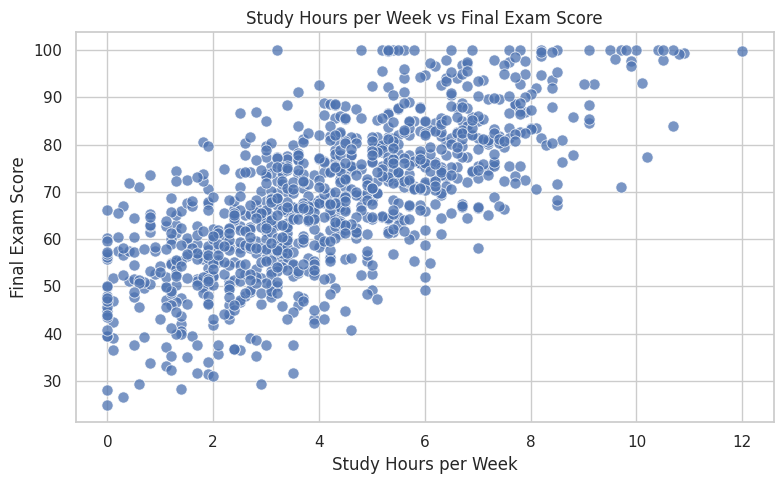

In [5]:
correlation = regression_df[feature].corr(regression_df[target])
print(f'Pearson correlation: {correlation:.3f}')

plt.figure(figsize=(8, 5))
sns.scatterplot(data=regression_df, x=feature, y=target, s=65, alpha=0.75)
plt.title('Study Hours per Week vs Final Exam Score')
plt.xlabel('Study Hours per Week')
plt.ylabel('Final Exam Score')
plt.tight_layout()
plt.show()

## 6. Define $X$ and $y$, Then Split the Data

An 80:20 split is used. `random_state=42` makes the result reproducible.

In [6]:
X = regression_df[[feature]]  # Two-dimensional input for scikit-learn
y = regression_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training samples: 790
Testing samples : 198


## 7. Train the Linear Regression Model

The model learns the equation $\hat{y} = b_0 + b_1X$, where $b_0$ is the intercept and $b_1$ is the slope.

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

intercept = model.intercept_
slope = model.coef_[0]

print(f'Intercept (b0): {intercept:.4f}')
print(f'Slope (b1)    : {slope:.4f}')
print(f'Learned equation: Predicted Final Score = {intercept:.4f} + ({slope:.4f} × Study Hours)')

Intercept (b0): 47.6002
Slope (b1)    : 4.9317
Learned equation: Predicted Final Score = 47.6002 + (4.9317 × Study Hours)


### Interpretation of the Slope

A positive slope means the predicted final-exam score increases as weekly study hours increase. The slope represents the expected score change associated with one additional study hour per week.

## 8. Predict the Test Set

In [8]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Study Hours': X_test[feature].values,
    'Actual Score': y_test.values,
    'Predicted Score': y_pred
})
results['Residual'] = results['Actual Score'] - results['Predicted Score']
display(results.round(2).head(15))

,Study Hours,Actual Score,Predicted Score,Residual
0,6.5,81.4,79.66,1.74
1,5.5,64.7,74.72,-10.02
2,2.2,52.7,58.45,-5.75
3,4.3,63.1,68.81,-5.71
4,6.3,81.8,78.67,3.13
5,6.5,88.1,79.66,8.44
6,1.0,43.1,52.53,-9.43
7,3.9,64.5,66.83,-2.33
8,0.2,57.5,48.59,8.91
9,3.0,57.9,62.40,-4.50


## 9. Evaluate Model Performance

- **MAE:** average absolute prediction error
- **MSE:** average squared prediction error
- **RMSE:** error in the same unit as exam scores
- **$R^2$:** proportion of target variation explained by the model

In [9]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared'],
    'Value': [mae, mse, rmse, r2]
})
display(metrics.round(4))

print(f'On average, predictions differ from actual scores by approximately {mae:.2f} marks (MAE).')
print(f'The model explains {r2 * 100:.2f}% of the variation in final-exam scores.')

,Metric,Value
0,MAE,7.5161
1,MSE,94.4077
2,RMSE,9.7164
3,R-squared,0.5085


On average, predictions differ from actual scores by approximately 7.52 marks (MAE).
The model explains 50.85% of the variation in final-exam scores.


## 10. Plot the Regression Line

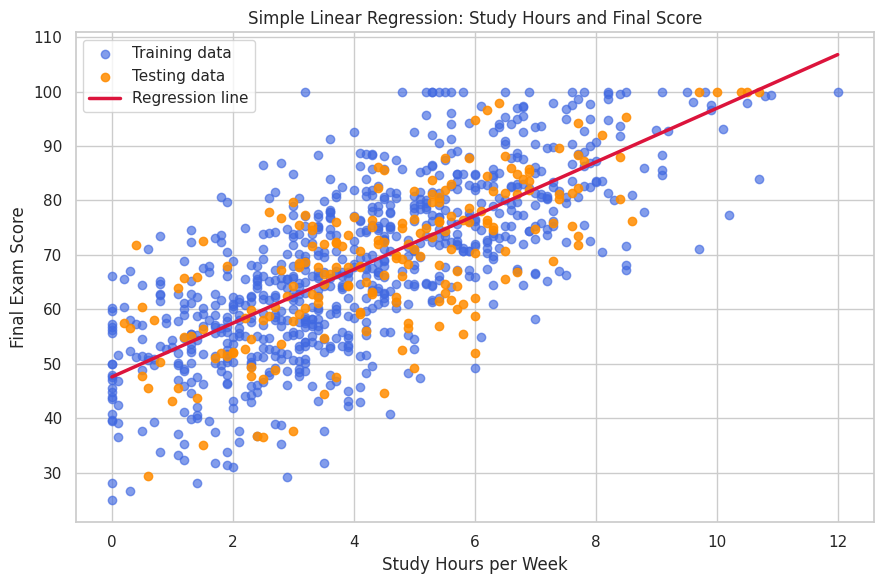

In [10]:
x_line = np.linspace(X[feature].min(), X[feature].max(), 200)
y_line = model.predict(pd.DataFrame({feature: x_line}))

plt.figure(figsize=(9, 6))
plt.scatter(X_train[feature], y_train, color='royalblue', alpha=0.65, label='Training data')
plt.scatter(X_test[feature], y_test, color='darkorange', alpha=0.85, label='Testing data')
plt.plot(x_line, y_line, color='crimson', linewidth=2.5, label='Regression line')
plt.title('Simple Linear Regression: Study Hours and Final Score')
plt.xlabel('Study Hours per Week')
plt.ylabel('Final Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Residual Analysis

Residuals should be scattered around zero without a strong curve or funnel pattern.

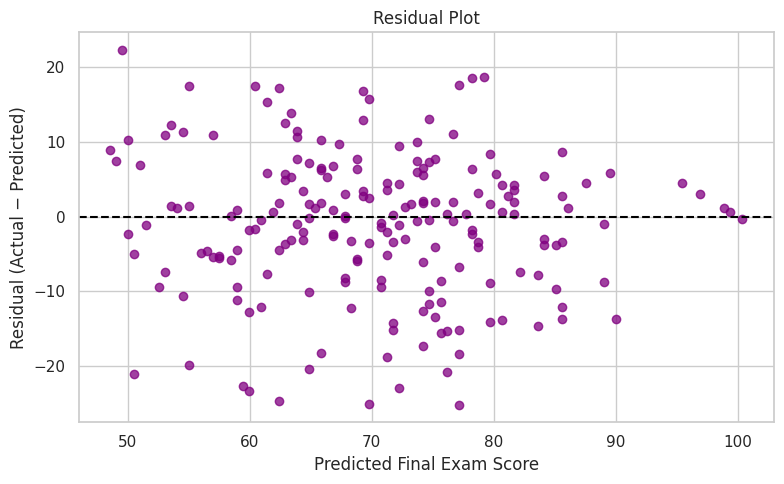

In [11]:
residuals = y_test.values - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, color='purple', alpha=0.75)
plt.axhline(0, color='black', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Final Exam Score')
plt.ylabel('Residual (Actual − Predicted)')
plt.tight_layout()
plt.show()

## 12. Predict a Score for New Study Hours

In [14]:
new_study_hours = 12
new_data = pd.DataFrame({feature: [new_study_hours]})
predicted_score = model.predict(new_data)[0]

print(f'Study hours per week: {new_study_hours}')
print(f'Predicted final exam score: {predicted_score:.2f}')

Study hours per week: 12
Predicted final exam score: 106.78


## 13. Conclusion

A simple linear regression model was trained on the Student Performance dataset to predict `final_exam_score` using `study_hours_per_week`. The regression equation, prediction table, MAE, MSE, RMSE, $R^2$, regression plot, and residual plot help assess both the model's performance and limitations.

### Important Limitation
A student's score depends on more than study hours. Attendance, test scores, assignment submission, subject, and other factors may improve prediction in a future **multiple linear regression** experiment.

## Viva Questions

1. What is the difference between an independent and dependent variable?
2. Why is this called simple linear regression?
3. What do the slope and intercept represent?
4. Why do we split data into training and testing sets?
5. What do MAE, RMSE, and $R^2$ measure?
6. What is a residual?
7. Does correlation prove causation? Explain.
8. Why might study hours alone be insufficient to predict examination scores?